# SI figure · The stiff probe, run twice, and the earlier stiff lever

The main text uses one stiff-probe run (R2). This SI figure shows the repeat on the same lever
(R1, the afternoon before; a load ladder during R1 changed the tip) and the draft's original
benchmark on an earlier SCM-PIT lever (Grid B, 241 positions).

- **a** CR1 enhancement E(x) of both runs in the lever frame, with each run's blind EB prediction.
- **b** Domain-CPD-corrected quasi-static d33 and CR1 ÷ blind-EB d33 for both runs.
- **c** On-resonance CR2 and CR3 mode shapes of the two dense maps, lever frame.
- **d** R1 → R2 shifts of every resonance and node, lever frame vs stage frame.
- **e** Live wideband reconstruction error vs rank, both runs (notebook 04).
- **f** Grid B benchmark (draft Figs 2–3): held-out CR1-band NRMSE vs N.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import datetime as dt, json
from fmmpaper import calib, eb_fit, axis
VAC, L_UM = 1.0, 226.5
RUNS = {"R1": ("DomainsB_SCMPIT", dt.datetime(2026, 9, 20, 11)),
        "R2": ("DomainsB_SCMPIT_R2", dt.datetime(2026, 9, 20, 22))}
CACHE = F.config.RESULTS_DIR / "_cache_fig6.json"
cache = json.loads(CACHE.read_text()) if CACHE.exists() else {}
T = {}
for tag, (camp, d0) in RUNS.items():
    s = F.load(f"scmpitB_{tag.lower()}_bias")
    tl = calib.timeline(camp, d0)
    x0 = float(calib.frame_anchors(camp, tl, L_UM).set_index("stage").loc["10_bias_survey", "x0"])
    pre = axis.invols_interpolator(F.load(f"scmpitB_{tag.lower()}_preflight"))
    # each stop's own force curve (ratio to pre-flight); stage median where a stop has none (R1's first stop)
    inv_fn = lambda x, _pre=pre, _tl=tl: float(np.atleast_1d(_pre(x))[0]) * float(calib.factor_at(_tl, "10_bias_survey", x)[0])
    t = domains.transfer_table(s, inv_fn, VAC)
    t["x_lever_um"] = t.x_um - x0
    # contact state for the blind fit: frequencies from the 0 V spot-1 spectra, Q1, static shape
    i0 = int(np.intersect1d(s.where(bias_V=0), s.where(spot=1))[0])
    fr = [float(np.median(spectra.peaks_along_x(s.freq_Hz, s.Z[i0], s.probe.bands_Hz[b])["f_Hz"])) for b in ("CR1", "CR2", "CR3")]
    xs = t.x_lever_um.values; keep = xs < L_UM - 10
    st = eb_fit.ContactState(f"{tag} survey", np.array(fr), float(np.nanmedian(t.Q)), xs[keep], t.invols.values[keep], L_um=L_UM)
    VARIANTS = {"central": dict(sig_f=0.015, sig_static=0.02, sig_Q=0.05), "sf1": dict(sig_f=0.01, sig_static=0.02, sig_Q=0.05),
                "sf2": dict(sig_f=0.02, sig_static=0.02, sig_Q=0.05), "archived": {}}
    lo = eb_fit.LO.copy(); lo[1] = -1.5
    cache.setdefault(tag, {})
    for vk, kw in VARIANTS.items():
        if vk not in cache[tag]:
            r = eb_fit.fit(st, use_nodes=False, lo=lo, **kw)
            cache[tag][vk] = dict(p=r.x.tolist(), summary={k: v for k, v in eb_fit.summarize(r.x, st).items() if k != "nodes_meas_um"})
            CACHE.write_text(json.dumps(cache, default=float))
    Es = {vk: eb_fit.enhancement(np.array(cache[tag][vk]["p"]), st, t.x_lever_um.values)[0] for vk in VARIANTS}
    t["E_eb"] = Es["central"]
    t["E_eb_lo"] = np.min(list(Es.values()), axis=0); t["E_eb_hi"] = np.max(list(Es.values()), axis=0)
    t["d33_cr_eb"] = domains.d33_from_enhancement(t, Es["central"], VAC)
    t["d33_cr_eb_lo"] = domains.d33_from_enhancement(t, t.E_eb_hi.values, VAC)
    t["d33_cr_eb_hi"] = domains.d33_from_enhancement(t, t.E_eb_lo.values, VAC)
    contact = L_UM - cache[tag]["central"]["summary"]["setback_um"]
    t["interior"] = t.x_lever_um < contact - 3          # at/after the tip contact the ratio is ill-defined
    # domain-dependent contact potential: P = p + delta*b(x); delta from the QS channel (uniform d33), applied to both channels
    cs = domains.cpd_split(t, mask=t.interior)
    for c in ("d33_qs", "E", "d33_cr_eb", "d33_cr_over_Q"):
        t[c + "_raw"] = t[c]
    t["d33_qs"] = cs["d33_qs_corr"]; t["E"] = cs["E_corr"]
    t["d33_cr_eb"] = cs["P_cr_corr"] / t.E_eb
    t["d33_cr_eb_lo"] = cs["P_cr_corr"] / t.E_eb_hi; t["d33_cr_eb_hi"] = cs["P_cr_corr"] / t.E_eb_lo
    t["d33_cr_over_Q"] = cs["P_cr_corr"] / t.Q
    print(f"{tag}: domain contact-potential term delta = {1e3*cs['delta_V']:+.0f} mV (V1 - V2 = {1e3*cs['dV_domains_V']:+.0f} mV), "
          f"uniform QS d33 {cs['d33_uniform']:.2f} pm/V")
    T[tag] = dict(table=t, x0=x0, contact_um=contact, state=st, cpd={k: cs[k] for k in ("delta_V", "dV_domains_V", "d33_uniform")})
    sm = cache[tag]["central"]["summary"]
    print(f"{tag}: x0 {x0:.1f} um, contact at {contact:.1f} um from clamp, k*/k {sm['k_ratio']:.0f}, kcone/k {sm['kcone_ratio']:.2f}, "
          f"setback {sm['setback_um']:.1f}, tip h {sm['tip_height_um']:.1f}, CR err % {sm['cr_err_pct']}, Q model {sm['Q_model']:.0f} vs {st.Q1:.0f}")

R1: domain contact-potential term delta = +353 mV (V1 - V2 = -706 mV), uniform QS d33 7.35 pm/V
R1: x0 5.5 um, contact at 224.0 um from clamp, k*/k 479, kcone/k 0.04, setback 2.5, tip h 7.7, CR err % [-0.63, 0.39, -0.09], Q model 221 vs 222


R2: domain contact-potential term delta = +635 mV (V1 - V2 = -1271 mV), uniform QS d33 7.58 pm/V
R2: x0 24.1 um, contact at 221.3 um from clamp, k*/k 734, kcone/k 0.23, setback 5.2, tip h 7.8, CR err % [-1.44, 0.94, -0.4], Q model 239 vs 238


In [3]:
C5 = json.loads((F.config.RESULTS_DIR / "fig5_contact_state.json").read_text())["values"]
nodes = pd.DataFrame(C5["nodes"])
X0_DENSE = nodes.groupby("run").x0_at_time.mean().to_dict()       # clamp position during each dense map
print("x0 during the dense maps (mean over the node times):", {k: round(v, 1) for k, v in X0_DENSE.items()},
      " spread", nodes.groupby("run").x0_at_time.agg(lambda s: round(s.max() - s.min(), 1)).to_dict())
b1, b2 = F.load("scmpitB_r1_dense"), F.load("scmpitB_r2_dense")
PROF = {}
for tag, s in (("R1", b1), ("R2", b2)):
    xl = s.x_um - X0_DENSE[tag]
    for b in ("CR1", "CR2", "CR3"):
        f0, v = spectra.on_resonance_profile(s.freq_Hz, s.Z[0], s.probe.bands_Hz[b])
        PROF[(tag, b)] = (xl, np.abs(v) / np.abs(v).max(), f0)
C3 = json.loads((F.config.RESULTS_DIR / "fig3a_scmpitB_generality.json").read_text())["values"]["nodes"]
fr = pd.DataFrame(C3).pivot(index="mode", columns="run", values="f_kHz")
fr["shift_pct"] = 100 * (fr.R2 / fr.R1 - 1)
nd = nodes.assign(k=nodes.groupby(["run", "mode"]).cumcount()).pivot(index=["mode", "k"], columns="run", values="lever_frame_um")
nd["shift_lever_um"] = nd.R2 - nd.R1
nd_stage = nodes.assign(k=nodes.groupby(["run", "mode"]).cumcount()).pivot(index=["mode", "k"], columns="run", values="old_frame_um")
nd["shift_fixed_frame_um"] = nd_stage.R2 - nd_stage.R1
L4 = pd.read_csv(F.config.RESULTS_DIR / "fig4_live_fmm.csv")
from fmmpaper import published
T3 = pd.read_csv(F.config.RESULTS_DIR / "fig3_gridB_error_vs_N.csv")
ebgp = published.load("regen").query("strategy == 'equispaced' and arm in ['eb_gp', 'ebgp3']").sort_values('arm').groupby('n').last()
print(fr.round(2)); print(nd.round(1))

x0 during the dense maps (mean over the node times): {'R1': 12.3, 'R2': 28.1}  spread {'R1': 2.1, 'R2': 1.2}


run        R1       R2  shift_pct
mode                             
CR1    285.00   295.33       3.62
CR2    884.61   915.03       3.44
CR3   1702.43  1837.36       7.93
run        R1     R2  shift_lever_um  shift_fixed_frame_um
mode k                                                    
CR2  0  126.7  124.9            -1.8                  14.0
CR3  0   89.6   88.3            -1.4                  14.0
     1  162.7  157.5            -5.2                  11.0


PosixPath('/home/claude/work/paper_analysis/results/si_stiff_repeat.json')

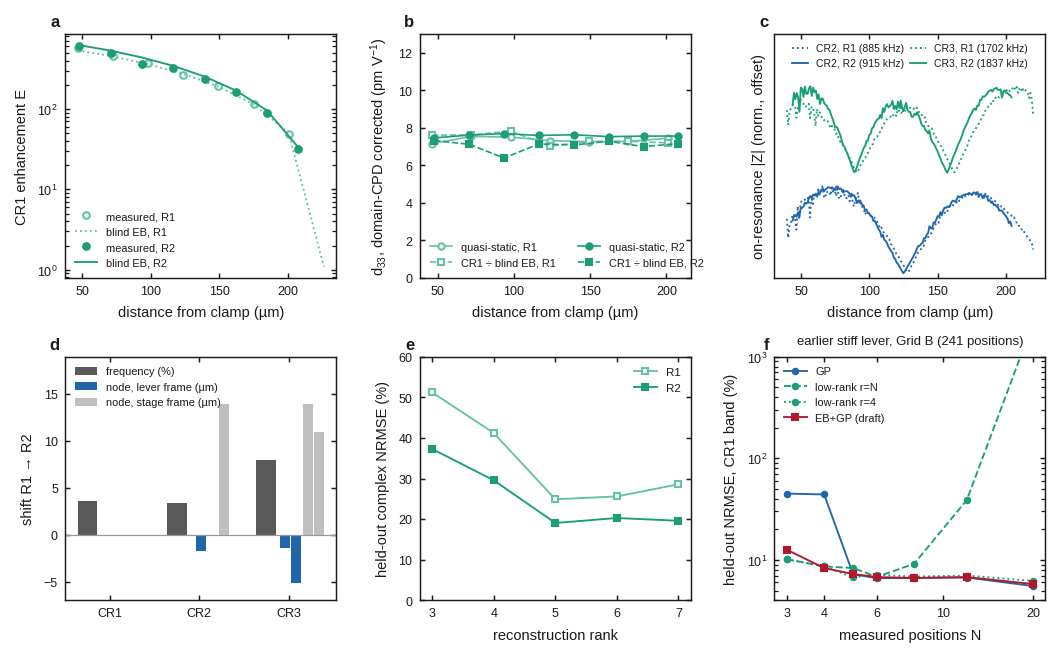

In [4]:
fig, ax = fp.figure("double", aspect=0.62, nrows=2, ncols=3)
ax = ax.ravel(); RC = {"R1": "#66c2a4", "R2": "#1b9e77"}
for tag, v in T.items():
    t = v["table"]; ti = t[t.interior]; c = RC[tag]
    ax[0].semilogy(ti.x_lever_um, ti.E, "o", color=c, mfc="w" if tag == "R1" else c, ms=3.2, label=f"measured, {tag}")
    ax[0].plot(t.x_lever_um, t.E_eb, "-" if tag == "R2" else ":", color=c, lw=0.9, label=f"blind EB, {tag}")
    ax[1].plot(ti.x_lever_um, ti.d33_qs, "o-", color=c, mfc="w" if tag == "R1" else c, ms=3, lw=0.8, label=f"quasi-static, {tag}")
    ax[1].plot(ti.x_lever_um, ti.d33_cr_eb, "s--", color=c, mfc="w" if tag == "R1" else c, ms=3, lw=0.8, label=f"CR1 ÷ blind EB, {tag}")
ax[0].set_xlabel("distance from clamp (µm)"); ax[0].set_ylabel("CR1 enhancement E"); ax[0].legend(loc="lower left", fontsize=5.3)
ax[1].set_ylim(0, 13); ax[1].set_xlabel("distance from clamp (µm)"); ax[1].set_ylabel("d$_{33}$, domain-CPD corrected (pm V$^{-1}$)")
ax[1].legend(loc="lower left", fontsize=5.3, ncol=2)
for k, (b, c) in enumerate((("CR2", fp.C["cr2"]), ("CR3", fp.C["cr3"]))):
    for tag, ls in (("R1", ":"), ("R2", "-")):
        xl, a, f0 = PROF[(tag, b)]
        ax[2].plot(xl, a + 1.15 * k, ls, color=c, lw=0.9, label=f"{b}, {tag} ({f0/1e3:.0f} kHz)")
ax[2].set_ylim(-0.05, 2.75); ax[2].set_yticks([]); ax[2].set_xlabel("distance from clamp (µm)"); ax[2].set_ylabel("on-resonance |Z| (norm., offset)")
ax[2].legend(loc="upper center", fontsize=5, ncol=2, handlelength=1.5, columnspacing=0.6)
modes = ["CR1", "CR2", "CR3"]; nl = nd.reset_index()
ax[3].bar(np.arange(3) - 0.25, fr.loc[modes, "shift_pct"], width=0.22, color="0.35", label="frequency (%)")
for i, m in enumerate(modes):
    q = nl[nl["mode"] == m]
    for j, (_, r) in enumerate(q.iterrows()):
        dx = (j - (len(q) - 1) / 2) * 0.12
        ax[3].bar(i + 0.02 + dx, r.shift_lever_um, width=0.11, color=fp.C["gp"], label="node, lever frame (µm)" if (i, j) == (1, 0) else None)
        ax[3].bar(i + 0.28 + dx, r.shift_fixed_frame_um, width=0.11, color="0.75", label="node, stage frame (µm)" if (i, j) == (1, 0) else None)
ax[3].axhline(0, color="0.6", lw=0.6); ax[3].set_xticks(range(3)); ax[3].set_xticklabels(modes); ax[3].set_ylabel("shift R1 → R2")
ax[3].set_ylim(-7, 19); ax[3].legend(loc="upper left", fontsize=5.3)
for tag, c in RC.items():
    q = L4[L4.probe == f"SCM-PIT-B {tag}"]
    ax[4].plot(q["rank"], q.nrmse, "s-", color=c, mfc="w" if tag == "R1" else c, ms=3, lw=0.9, label=tag)
ax[4].set_xlabel("reconstruction rank"); ax[4].set_ylabel("held-out complex NRMSE (%)"); ax[4].set_ylim(0, 60); ax[4].legend(fontsize=5.5)
for arm, c, ls in (("GP", fp.C["gp"], "-"), ("low-rank r=N", fp.C["lowrank"], "--"), ("low-rank r=4", fp.C["lowrank"], ":")):
    d = T3[T3.arm == arm]
    ax[5].plot(d.n, d.nrmse_A, ls, color=c, marker="o", ms=2.6, lw=0.9, label=arm)
ax[5].plot(ebgp.index, ebgp.nrmse_A, "-", color=fp.C["ebgp"], marker="s", ms=2.6, lw=0.9, label="EB+GP (draft)")
fp.n_axis(ax[5]); ax[5].set_yscale("log"); ax[5].set_ylim(4, 1000)
ax[5].set_xlabel("measured positions N"); ax[5].set_ylabel("held-out NRMSE, CR1 band (%)"); ax[5].legend(loc="upper left", fontsize=5.3)
ax[5].set_title("earlier stiff lever, Grid B (241 positions)", fontsize=6.3)
for a, l in zip(ax, "abcdef"):
    fp.panel_label(a, l)
fig.tight_layout(); fp.save(fig, "SIc_stiff_repeat_and_gridB")
results.save("si_stiff_repeat", dict(cpd={k: v["cpd"] for k, v in T.items()}, freq_shift=fr.reset_index().to_dict("records"),
                                     node_shift=nd.reset_index().to_dict("records")))